In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Байесовская статистика

1) X1, ..., Xn ∼ Bern(θ), θ ∼ R[0, 1]. Посчитать апостериорную плотность и построить ее график.

а) для выборок размера n = 5, 10, 20, 50, 100 для θ = 1/2, θ = 1/3;

б) вместо генерации выборки положите Pn i=1 Xi равной 9n/10 или 99n/100.

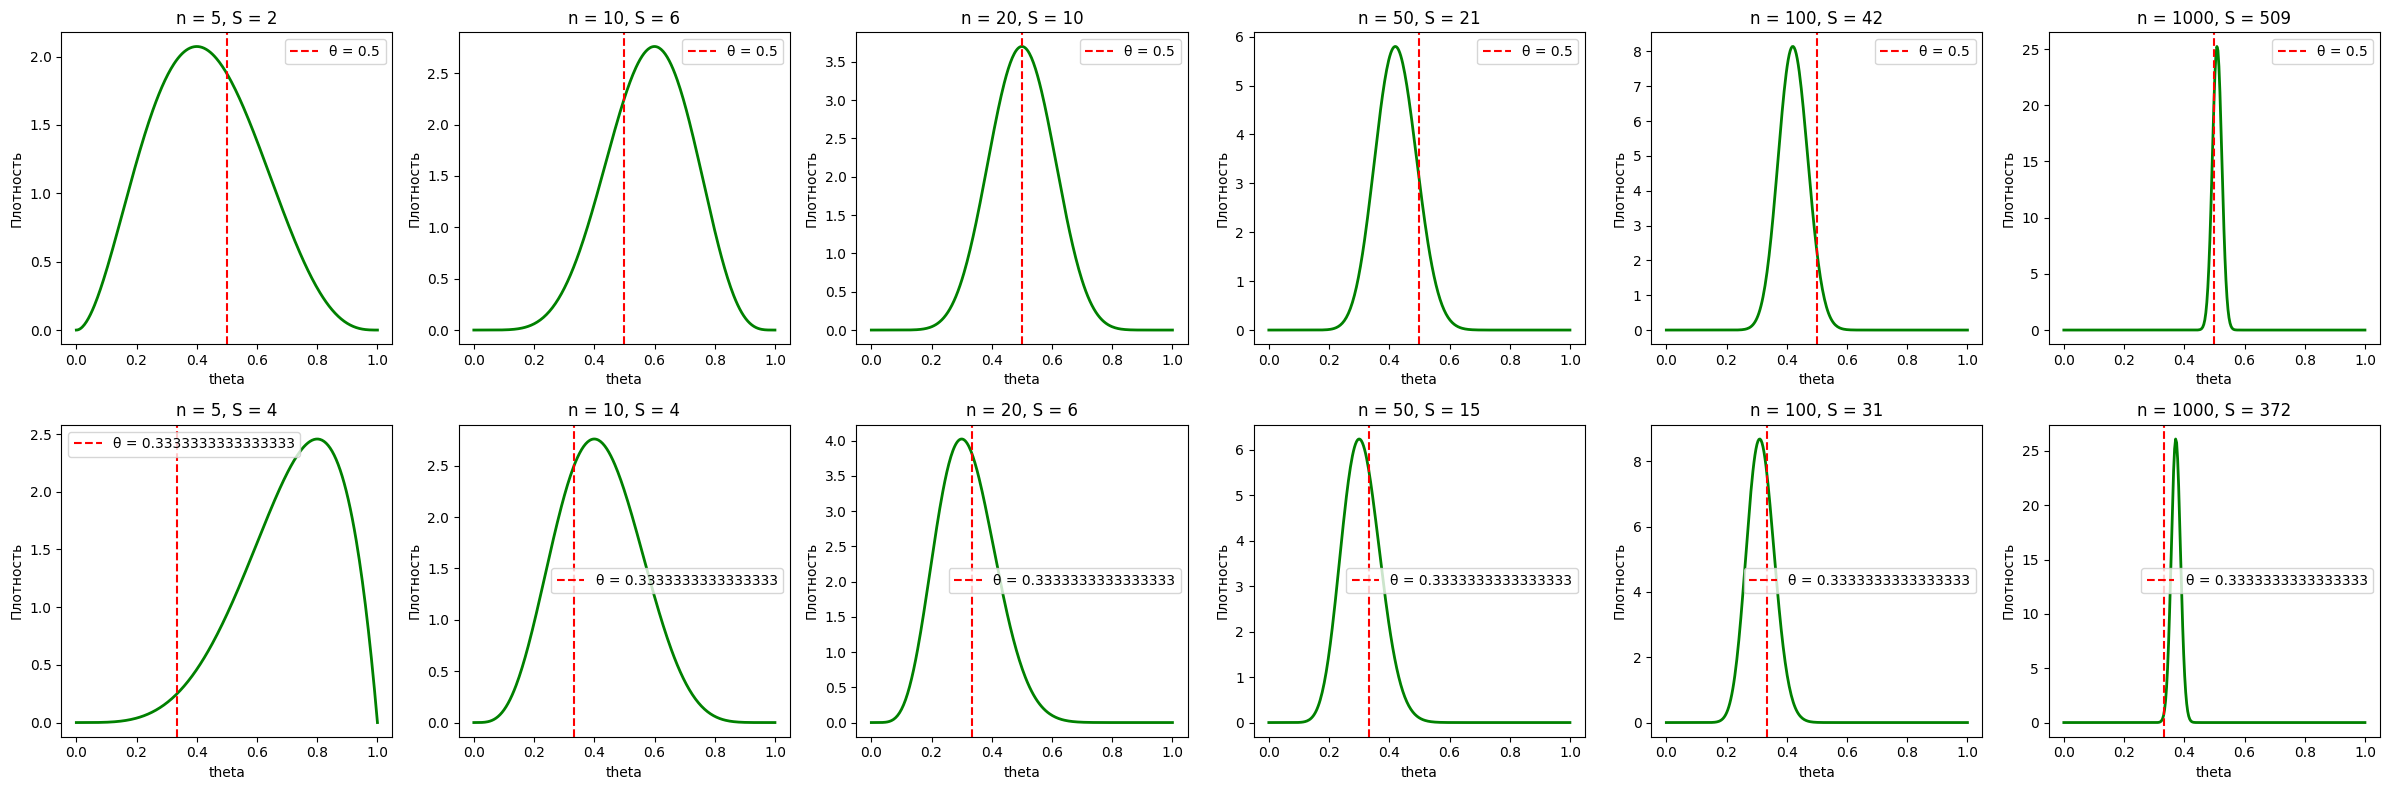

In [ ]:
true_thetas = [1/2, 1/3]
sample_sizes = [5, 10, 20, 50, 100, 1000]

fig, axes = plt.subplots(len(true_thetas), len(sample_sizes), figsize=(24, 8))

for i, theta_true in enumerate(true_thetas):
    for j, n in enumerate(sample_sizes):
        sample = np.random.binomial(1, theta_true, n)
        S = np.sum(sample)

        a_post = 1 + S
        b_post = 1 + n - S

        x = np.linspace(0, 1, 300)
        y = stats.beta.pdf(x, a_post, b_post)

        axes[i, j].plot(x, y, 'b-', linewidth=2)
        axes[i, j].axvline(x=theta_true, color='red', linestyle='--', label=f'θ = {theta_true}')
        axes[i, j].set_title(f'n = {n}, S = {S}')
        axes[i, j].set_xlabel('theta')
        axes[i, j].set_ylabel('Плотность')
        axes[i, j].legend()

plt.tight_layout()
plt.show()


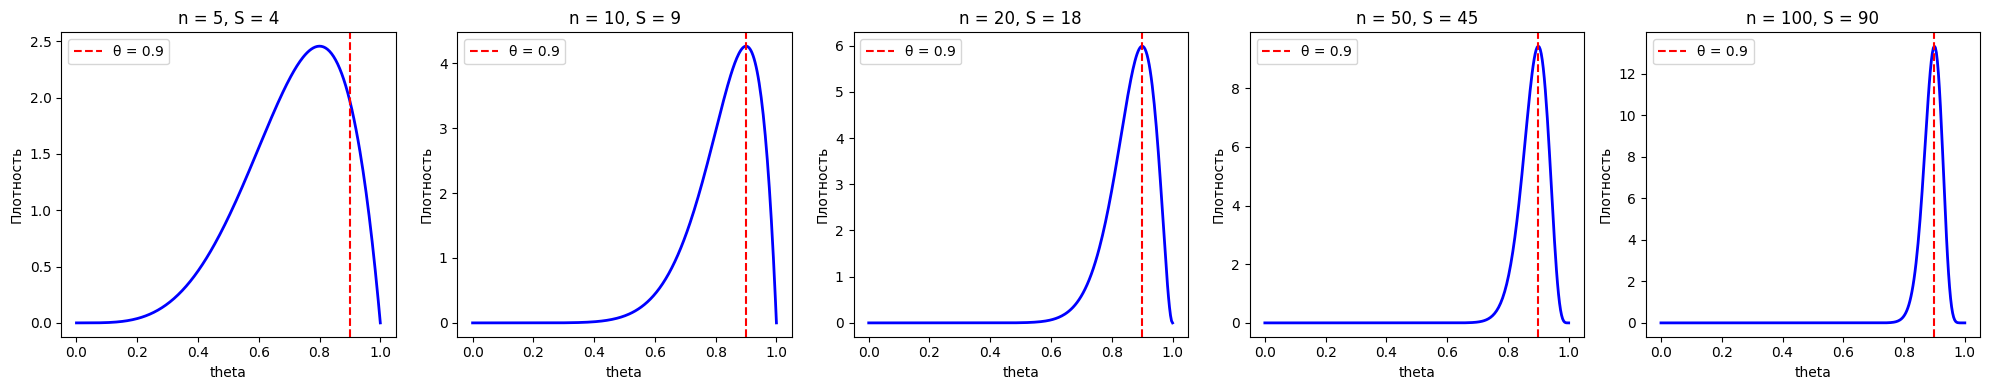

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

rat = 9/10
sample_sizes = [5, 10, 20, 50, 100]

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(20, 4))

for j, n in enumerate(sample_sizes):
    S = int(n * rat)

    a_post = 1 + S
    b_post = 1 + n - S

    x = np.linspace(0, 1, 300)
    y = beta.pdf(x, a_post, b_post)

    axes[j].plot(x, y, 'b-', linewidth=2)
    axes[j].axvline(x=rat, color='red', linestyle='--', label=f'θ = {rat}')
    axes[j].set_title(f'n = {n}, S = {S}')
    axes[j].set_xlabel('theta')
    axes[j].set_ylabel('Плотность')
    axes[j].legend()

plt.tight_layout()
plt.show()

2. Пусть X1, ..., Xn ∼ N (θ, 1), θ ∼ N (μ, σ2). Апостериорную плотность можно не считать, а взять из
таблицы. Посмотрим, как влияют параметры априорного распределения на итоговый результат. Для этого будем генерировать выборки для какого-то одного фиксированного θ (возьмите любое число из [0, 1], а также посмотрите на какое-нибудь θ, близкое к 0 или 1).

(a) Сравнить (визуально на графике) апостериорные плотности для нескольких разных значений
(μ, σ2).

(b) Построить пример, когда при n = 10000 оценка θ достаточно сильно отличается от настоящего
значения.

(c) Сравнить байесовские оценки для квадратичного риска при разных (μ, σ2).

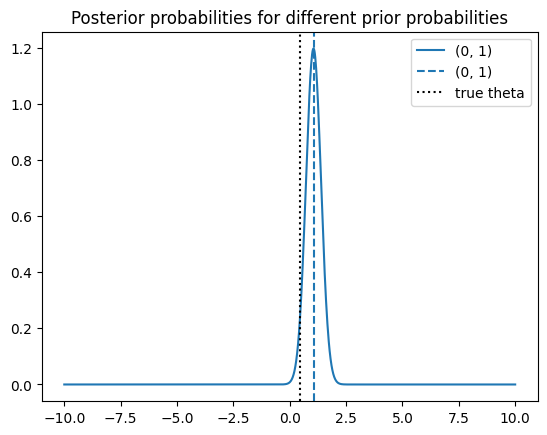

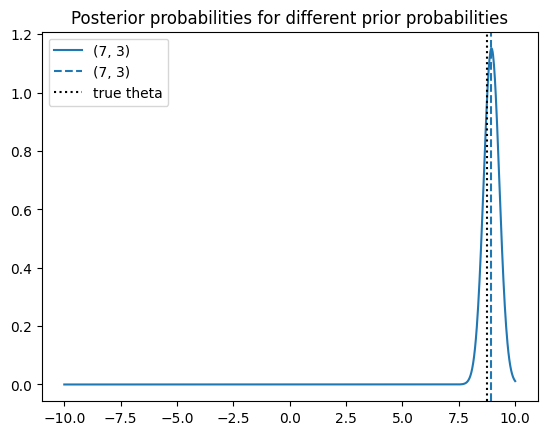

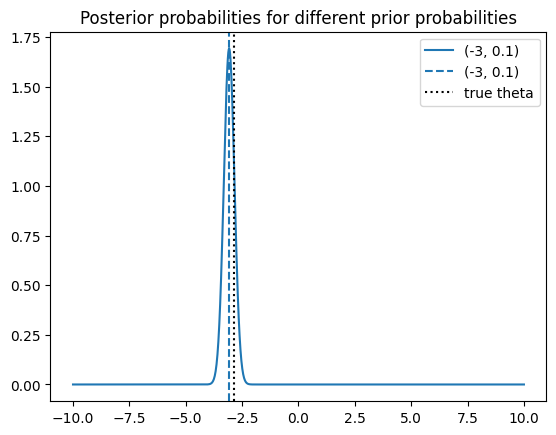

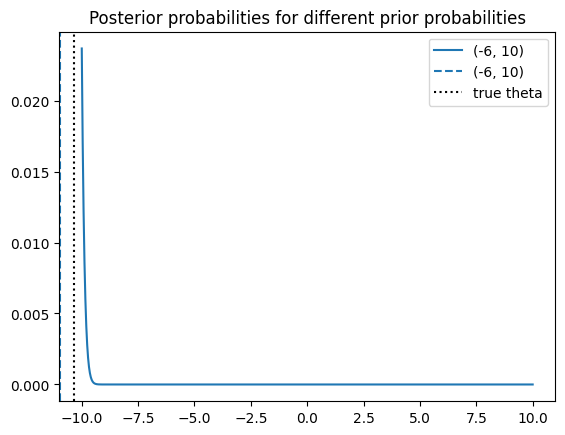

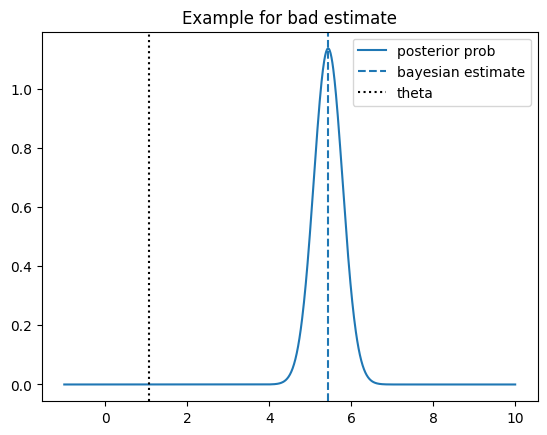

In [ ]:
params = [(0, 1), (7, 3), (-3, 0.1), (-6, 10)]
n =8
for p in params:
  theta = stats.norm.rvs(p[0], np.sqrt(p[1]))
  x_data = stats.norm.rvs(theta, 1, size = n)
  k = sum(x_data)
  post_mu = (p[0]/p[1] + k)/(1/p[1] + n)
  post_sigma = (p[1])/(1+n*p[1])
  x= np.linspace(-10,10, 1000)
  plt.plot(x, stats.norm.pdf(x, post_mu, np.sqrt(post_sigma)), label =f'({p[0]}, {p[1]})')
  plt.axvline(x = post_mu, label = f'({p[0]}, {p[1]})', linestyle = '--')
  plt.axvline(x = theta, linestyle = ':', color = 'black', label = 'true theta')
  plt.legend()
  plt.title("Posterior probabilities for different prior probabilities")
  plt.show()

#b ???
theta = stats.norm.rvs(0, 3)
x_data = stats.norm.rvs(theta+5, 1, size = n)

k = sum(x_data)
post_mu = (p[0]/p[1] + k)/(1/p[1] + n)
post_sigma = (p[1])/(1+n*p[1])
x= np.linspace(-1, 7, 1000)
plt.plot(x, stats.norm.pdf(x, post_mu, np.sqrt(post_sigma)), label =f'posterior prob')
plt.axvline(x = post_mu, label = f'bayesian estimate', linestyle = '--')
plt.axvline(x = theta, linestyle = ':', color = 'black',label='theta')
plt.legend()
plt.title('Example for bad estimate')
plt.show()

3) X1, ..., Xn ∼ N (θ, 1). Построить (на листочке) байесовский критерий для проверки H0 : θ = 0 против H1 : θ = 1, если априорная вероятность P(θ = 0) = p. Построить графики зависимости ошибок 1-го и 2-го рода от p.

/tmp/ipython-input-416448449.py:4: RuntimeWarning: invalid value encountered in log
  plt.plot(x, 1-stats.norm.cdf(np.log(x/(1-x))/np.sqrt(n) + np.sqrt(n)/2), label = '1 type error', color = 'firebrick')
/tmp/ipython-input-416448449.py:5: RuntimeWarning: invalid value encountered in log
  plt.plot(x, stats.norm.cdf(np.log(x/(1-x))/np.sqrt(n) - np.sqrt(n)/2), label = '2 type error', color = 'blueviolet' )


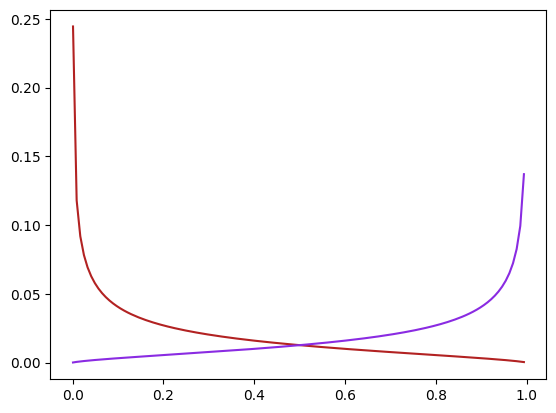

In [ ]:
n = 20

plt.plot(x, 1-stats.norm.cdf(np.log(x/(1-x))/np.sqrt(n) + np.sqrt(n)/2), label = '1 type error', color = 'firebrick')
plt.plot(x, stats.norm.cdf(np.log(x/(1-x))/np.sqrt(n) - np.sqrt(n)/2), label = '2 type error', color = 'blueviolet' )

4)* Пусть Xi ∼ exp(θ), а θ ∼ Gamma(a, b). а) Построить байесовские оценки для абсолютной и квад-
ратичной функций потерь и сравнить у таких оценок среднюю а) квадратичную б) абсолютную ошибку. б) Построить байесовский доверительный интервал уровня 95% и эмпирически исследо-
вать ее уровень доверия.

In [ ]:
k = 1000
alpha=0.05
n = 10
a, b = 6, 2
sq_sq = []
sq_abs = []
abs_sq = []
abs_abs = []

cover = 0

for i in range(k):
  theta = stats.gamma.rvs(a, loc = 0, scale = b)
  #theta = 1.5
  x_data = stats.expon.rvs(loc = 0, scale = 1/theta, size = n)

  #calculate estimates:
  sq_theta = (a+n)/(1/b + sum(x_data))
  abs_theta = stats.gamma.ppf(0.5, a = a+n,loc= 0,  scale = 1.0/(1.0/b + sum(x_data)))

  theta1 = stats.gamma.ppf(alpha/2, a = a+n, loc= 0,  scale = 1.0/(1.0/b + sum(x_data)))
  theta2 = stats.gamma.ppf(1-alpha/2, a = a+n, loc= 0,  scale = 1.0/(1.0/b + sum(x_data)))

  #print(theta, sq_theta, abs_theta, theta1, theta2)

  if theta1 <= theta <= theta2:
    cover += 1

  sq_sq.append((theta - sq_theta)**2)
  sq_abs.append(abs(theta - sq_theta))
  abs_sq.append((theta-abs_theta)**2)
  abs_abs.append(abs(theta-abs_theta))

print("    Error :    sq          abs")
print("Square estim: ", f'{np.mean(sq_sq):.3f};    {np.mean(sq_abs):.3f}')
print("Abs estimate: ", f'{np.mean(abs_sq):.3f};    {np.mean(abs_abs):.3f}')
print(f"\nCoverage: {cover/k}")


    Error :    sq          abs
Square estim:  9.968;    2.357
Abs estimate:  10.049;    2.349

Coverage: 0.949
